# Step 3 — Classical Baseline Anomaly Detectors

Goal:
Establish statistical and classical ML baselines before deep learning.

Methods:
1. Rolling Z-Score
2. PCA Reconstruction Error
3. Isolation Forest

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest

plt.style.use("default")

## 2. Load Windowed Data (From Step 2)

Shape format:
(num_windows, window_size, num_sensors)

In [11]:
X_train = np.load("data/X_train.npy")
X_val   = np.load("data/X_val.npy")
X_test  = np.load("data/X_test.npy")

print("Train shape:", X_train.shape)
print("Val shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (233, 80, 12)
Val shape: (68, 80, 12)
Test shape: (68, 80, 12)


## 3. Flatten Windows for Classical Models

Classical models require 2D input:
(samples, features)

In [12]:
n_train, T, n_features = X_train.shape
n_test = X_test.shape[0]

X_train_flat = X_train.reshape(n_train, T * n_features)
X_test_flat  = X_test.reshape(n_test, T * n_features)

print("Flattened train shape:", X_train_flat.shape)

Flattened train shape: (233, 960)


## 4. Global Z-Score Baseline

Mean and std computed from training windows only.

We use max aggregation per window to avoid diluting localized spikes.

In [13]:
# Compute mean/std per sensor (not per timestep)
train_mean = X_train.mean(axis=(0,1))   # shape: (15,)
train_std  = X_train.std(axis=(0,1))    # shape: (15,)

epsilon = 1e-4
train_std = np.where(train_std < epsilon, epsilon, train_std)

# Expand dimensions for broadcasting
train_mean = train_mean.reshape(1,1,-1)
train_std  = train_std.reshape(1,1,-1)

z_scores = np.abs((X_test - train_mean) / train_std)

z_window_score = z_scores.max(axis=(1,2))

### Z-Score Visualization

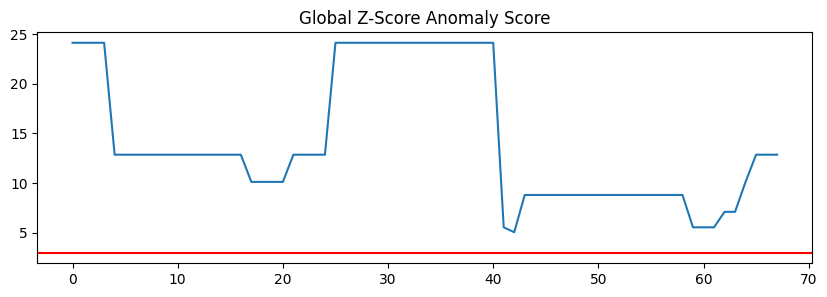

In [14]:
plt.figure(figsize=(10,3))
plt.plot(z_window_score)
plt.axhline(z_threshold, color="red")
plt.title("Global Z-Score Anomaly Score")
plt.show()

In [15]:
# Choose threshold (3 is standard for global z-score)
z_threshold = 3.0

z_anomalies = z_window_score > z_threshold

print("Z anomalies detected:", z_anomalies.sum())
print("Total test windows:", len(z_window_score))
print("Max Z-score:", z_window_score.max())
print("Mean Z-score:", z_window_score.mean())

Z anomalies detected: 68
Total test windows: 68
Max Z-score: 24.114311103571943
Mean Z-score: 14.304250758055666


In [17]:
print("Min Z-score:", z_window_score.min())
print("25th percentile:", np.percentile(z_window_score, 25))
print("50th percentile:", np.percentile(z_window_score, 50))
print("75th percentile:", np.percentile(z_window_score, 75))
print("Max Z-score:", z_window_score.max())

Min Z-score: 5.0662280511898174
25th percentile: 8.811911769278014
50th percentile: 12.861903880393868
75th percentile: 24.114311103571943
Max Z-score: 24.114311103571943


## 5. PCA Reconstruction Baseline

Fit PCA on training data.
Reconstruct test windows.
Compute reconstruction error.

In [18]:
# Fit PCA
pca = PCA(n_components=0.95)
pca.fit(X_train_flat)

# Training reconstruction error
X_train_recon = pca.inverse_transform(pca.transform(X_train_flat))
train_error = np.mean((X_train_flat - X_train_recon)**2, axis=1)

# Test reconstruction error
X_test_recon = pca.inverse_transform(pca.transform(X_test_flat))
pca_error = np.mean((X_test_flat - X_test_recon)**2, axis=1)

# Threshold from training distribution
pca_threshold = np.percentile(train_error, 95)

pca_anomalies = pca_error > pca_threshold

print("PCA anomalies detected:", pca_anomalies.sum())
print("PCA threshold:", pca_threshold)

PCA anomalies detected: 65
PCA threshold: 0.15910527307173267


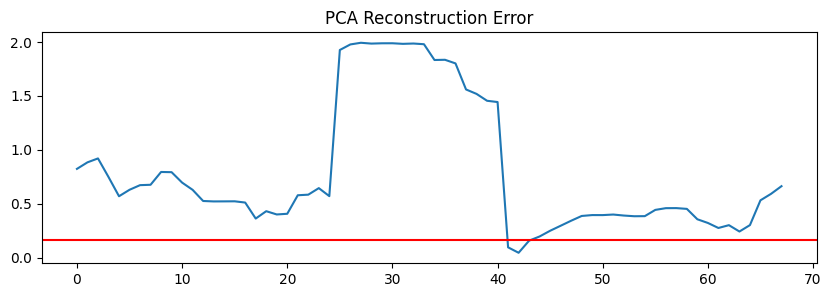

In [19]:
plt.figure(figsize=(10,3))
plt.plot(pca_error)
plt.axhline(pca_threshold, color="red")
plt.title("PCA Reconstruction Error")
plt.show()

In [20]:
print("Min PCA error:", pca_error.min())
print("25th percentile:", np.percentile(pca_error, 25))
print("50th percentile:", np.percentile(pca_error, 50))
print("75th percentile:", np.percentile(pca_error, 75))
print("Max PCA error:", pca_error.max())

Min PCA error: 0.04484516128240738
25th percentile: 0.3892769729799965
50th percentile: 0.5504175542992495
75th percentile: 0.8928599751206879
Max PCA error: 1.9928719637492671
